<a href="https://colab.research.google.com/github/MonishDY/AI-Track/blob/main/Module%202%20-%20Feature%20Engineering/Assignment%201/Machine_Learning_Case_Studies_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

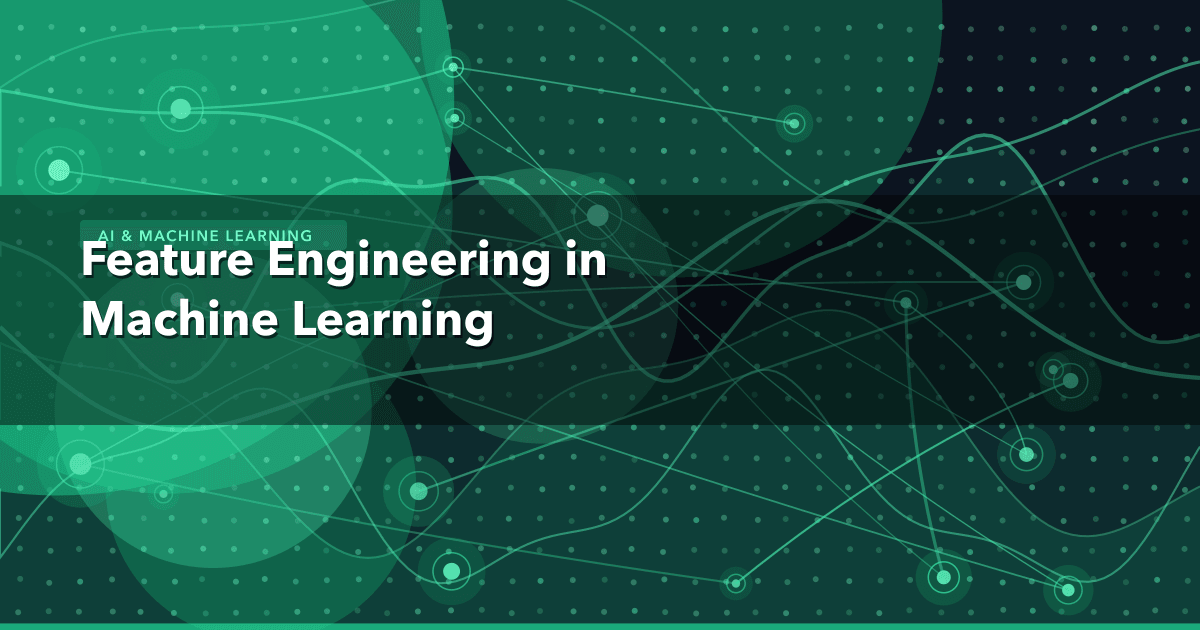

# **Machine Learning Case Studies**

## **Session Agenda**

During this session, we will explore the following Machine Learning concepts through practical case studies:

1. Feature Generation using BMI
2. Polynomial Feature Generation
3. Data Scaling - Min-Max Scaling, Z-Score Standardization
4. Principal Component Analysis (PCA)
5. Missing Value Imputation - Mean, Median, KNN, MICE
6. Outlier Detection using Z-Score
7. Feature Selection using Lasso Regularization

## **Learning Objectives**

By the end of this session, you will be able to:

- Create and transform features for machine learning models.
- Apply data preprocessing techniques such as scaling and imputation.
- Detect and remove outliers using statistical methods.
- Reduce dimensionality using Principal Component Analysis (PCA).
- Perform feature selection using Lasso Regularization.
- Implement these techniques using Python and Scikit-learn.

### **Importing the necessary libraries**

In [1]:
# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Imputation
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.datasets import make_regression

# Outlier Detection
from scipy.stats import zscore

# Train Test Split
from sklearn.model_selection import train_test_split

# Feature Selection
from sklearn.linear_model import Lasso

# Formatting options
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.figsize'] = (6, 4)


# **Case Study 1: Feature Generation (BMI)**

### **Problem**
A healthcare company wants to predict whether a patient is obese. Create a new feature called **Body Mass Index (BMI)** for each patient.

### **Dataset**

| Patient | Weight (kg) | Height (m) |
|---------|-------------:|-----------:|
| P1 | 70 | 1.75 |
| P2 | 90 | 1.80 |
| P3 | 110 | 1.70 |


### **Formula**
$BMI=\frac{\text{Weight (kg)}}{\left(\text{Height (m)}\right)^2}$

### **BMI Classification (WHO Standard)**

| BMI (kg/m²) | Classification |
|:-----------:|----------------|
| < 18.5 | Underweight |
| 18.5 - 24.9 | Normal weight |
| 25.0 - 29.9 | Overweight |
| > 30.0  | Obese|

### **Task**
- Create a new feature `BMI` using the above formula.
- Categorize the BMI as `Category` as Underweight, Normal, Overweight, Obese.
- Create a new feature `isObese` which tells a person is Obese or not.
- Display the updated dataset.

## **i. Mathematical Computation**

For each patient,

**Patient P1**

$$
BMI = \frac{70}{(1.75)^2}
=\frac{70}{3.0625}
=22.86
$$

**Patient P2**

$$
BMI = \frac{90}{(1.80)^2}
=\frac{90}{3.24}
=27.78
$$

**Patient P3**

$$
BMI = \frac{110}{(1.70)^2}
=\frac{110}{2.89}
=38.06
$$

### **Final BMI Results**

| Patient | BMI (kg/m²) | WHO Category |
|:-------:|:-----------:|--------------|
| P1 | 22.86 | Normal weight |
| P2 | 27.78 | Overweight |
| P3 | 38.06 | Obese |



## **ii. Code Implementation**

We'll first create the dataset for the patients showing their weight (kg) and height (m).

In [2]:
# Create the dataset
data = {
    "Patient": ["P1", "P2", "P3"],
    "Weight (kg)": [70, 90, 110],
    "Height (m)": [1.75, 1.80, 1.70]
}

df1 = pd.DataFrame(data)
df1

,Patient,Weight (kg),Height (m)
0,P1,70,1.7500
1,P2,90,1.8000
2,P3,110,1.7000


Create a new feature `BMI` using weight and height using the given formula.

In [3]:
# Calculate BMI
df1["BMI"] = (df1["Weight (kg)"] / (df1["Height (m)"] ** 2))

Create a function `bmi_category` that tells the category of the bmi as Underweight, Normal, Overweight or Obese.

In [4]:
# Define a function for BMI category
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

Create new features `Category` for having the BMI Category and `isObese` for checking the person is Obese or not.

In [5]:
# Update the new features Category and isObese
df1["Category"] = df1["BMI"].apply(bmi_category)
df1["Is Obese"] = (df1["BMI"] >= 30).astype(int)
df1

,Patient,Weight (kg),Height (m),BMI,Category,Is Obese
0,P1,70,1.7500,22.8571,Normal,0
1,P2,90,1.8000,27.7778,Overweight,0
2,P3,110,1.7000,38.0623,Obese,1


### **Inference**

- **Patient P1** has a BMI of **22.86**, **P2** has a BMI of **27.78**, and **P3** has a BMI of **38.06**, indicating **Normal**, **Overweight**, and **Obese**, respectively.
- Since only **P3** has a BMI greater than **30**, only **P3** is classified as obese (`Is Obese = 1`).

## **iii. Visual Analysis**

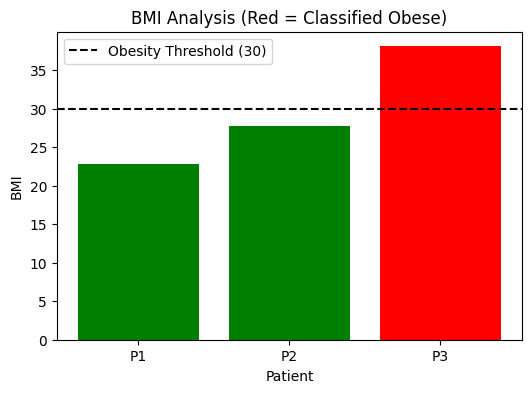

In [6]:
# # Plot BMI values --> Green = Not Obese, Red = Obese
colors = ["green" if x == 0 else "red" for x in df1["Is Obese"]]
plt.bar(df1["Patient"], df1["BMI"], color=colors)

# Obesity threshold
plt.axhline(30, linestyle="--", color="black", label="Obesity Threshold (30)")

# Labels and title
plt.title("BMI Analysis (Red = Classified Obese)")
plt.xlabel("Patient")
plt.ylabel("BMI")
plt.legend()

plt.show()

### **Inference:**
- The **red bar** indicates that **P3** is obese (BMI > 30), while the **green bars** show that **P1** and **P2** are not obese.

# **Case Study 2: Polynomial Features**


### **Problem**
An automobile company wants to predict fuel consumption based on speed.

### **Dataset**

| Speed |
|------:|
| 20 |
| 40 |
| 60 |


### **Task**
- Generate polynomial features up to **Degree 4** including:

$$
\text{Speed},\;
\text{Speed}^2,\;
\text{Speed}^3,\;
\text{Speed}^4
$$

- Display the transformed dataset.

## **i. Mathematical Computation**

Generate polynomial features up to degree 4 for each speed value. The transformed features are:

$$ Speed, Speed^2, Speed^3, Speed^4 $$

**Speed = 20**

$$20$$
$$20^2 = 400$$
$$20^3 = 8000$$
$$20^4 = 160000$$

**Speed = 40**

$$40$$
$$40^2 = 1600$$
$$40^3 = 64000$$
$$40^4 = 2560000$$

**Speed = 60**

$$60$$
$$60^2 = 3600$$
$$60^3 = 216000$$
$$60^4 = 12960000$$

### **Final Polynomial Features**

| Speed | Speed² | Speed³ | Speed⁴ |
|------:|-------:|-------:|--------:|
| 20 | 400 | 8,000 | 160,000 |
| 40 | 1,600 | 64,000 | 2,560,000 |
| 60 | 3,600 | 216,000 | 12,960,000 |

## **ii. Code Implementation**

We'll first create the dataset for Speed.

In [7]:
# Create the dataset
df2 = pd.DataFrame({"Speed": [20, 40, 60]})
df2

,Speed
0,20
1,40
2,60


Calculate its polynomial features `Speed^2`, `Speed^3`, `Speed^4` manually and display them.

In [8]:
# Compute polynomial features manually
manual_poly = pd.DataFrame({
    "1": df2["Speed"] ** 0,
    "Speed": df2["Speed"] ** 1,
    "Speed^2": df2["Speed"] ** 2,
    "Speed^3": df2["Speed"] ** 3,
    "Speed^4": df2["Speed"] ** 4,
})

manual_poly

,1,Speed,Speed^2,Speed^3,Speed^4
0,1,20,400,8000,160000
1,1,40,1600,64000,2560000
2,1,60,3600,216000,12960000


Now calculate the polynomial features using the **PolynomialFeatures(degree = 4)** function and display them.

In [9]:
# Generate polynomial features
poly = PolynomialFeatures(degree=4, include_bias=True)
poly_features = poly.fit_transform(df2)
poly_features

array([[       1.,       20.,      400.,     8000.,   160000.],
       [       1.,       40.,     1600.,    64000.,  2560000.],
       [       1.,       60.,     3600.,   216000., 12960000.]])

In [10]:
# Create a DataFrame
poly_df = pd.DataFrame(
    poly_features,
    columns=poly.get_feature_names_out(df2.columns)
)

# Display the transformed dataset
poly_df

,1,Speed,Speed^2,Speed^3,Speed^4
0,1.0000,20.0000,400.0000,"8,000.0000","160,000.0000"
1,1.0000,40.0000,"1,600.0000","64,000.0000","2,560,000.0000"
2,1.0000,60.0000,"3,600.0000","216,000.0000","12,960,000.0000"


### **Inference**

- As the speed increases from **20** to **60**, the polynomial feature values increase rapidly, especially for higher-degree terms (**Speed^3** and **Speed^4**).
- Higher-degree polynomial features capture the non-linear relationship in the data, making them useful for polynomial regression models.

## **iii. Visual Analysis**

We'll now compare how polynomial features affect the change of values in each degree.

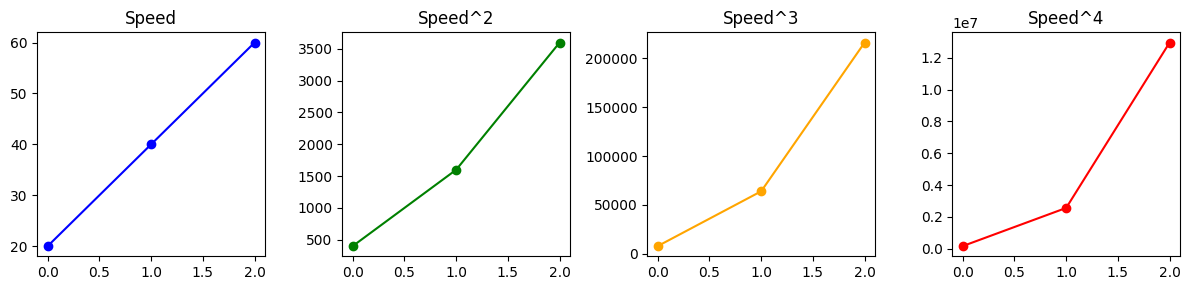

In [11]:
# Use subplots to visualize how the polynomial features affect the sample
fig, ax = plt.subplots(1, 4, figsize=(12, 3))

ax[0].plot(poly_df["Speed"],   marker="o", color="blue");   ax[0].set_title("Speed")
ax[1].plot(poly_df["Speed^2"], marker="o", color="green");  ax[1].set_title("Speed^2")
ax[2].plot(poly_df["Speed^3"], marker="o", color="orange"); ax[2].set_title("Speed^3")
ax[3].plot(poly_df["Speed^4"], marker="o", color="red");    ax[3].set_title("Speed^4")

plt.tight_layout()
plt.show()

### **Inference**
- Each individual line plot shows an increasing trend, with the **Speed^4** plot rising the fastest, followed by **Speed^3**, **Speed^2**, and **Speed**, indicating that higher-degree polynomial features grow much more rapidly.

# **Case Study 3: MinMax Scaling and Z-Score Scaling**

### **Problem**
An HR team wants to scale employee income. Normalize employee income using two scaling techniques.

### **Dataset**

| Income |
|--------:|
| 30000 |
| 50000 |
| 70000 |
| 90000 |

### **Tasks**

1. Apply **MinMax Scaling**
2. Apply **Z-Score Standardization**

Display both transformed datasets.

## **i. Mathematical Computation**

Given Income values:

$$ 30000, 50000, 70000, 90000 $$

### **a) Min-Max Scaling**

**Formula:**
$$ x'=\frac{x-x_{\min}}{x_{\max}-x_{\min}} $$

Here, $$ x_{\min}=30000,\qquad x_{\max}=90000 $$

**For 30000,**

$$
\frac{30000-30000}{90000-30000}=0
$$

**For 50000,**

$$
\frac{50000-30000}{90000-30000}=0.33
$$

**For 70000,**

$$
\frac{70000-30000}{90000-30000}=0.67
$$

**For 90000,**

$$
\frac{90000-30000}{90000-30000}=1
$$

### **b) Z-Score Scaling**

**Formula:**

$$
z = \frac{x-\mu}{\sigma}
$$

Mean:

$$
\mu=\frac{30000+50000+70000+90000}{4}=60000
$$

Standard Deviation:

$$
\sigma=\sqrt{\frac{(30000-60000)^2+(50000-60000)^2+(70000-60000)^2+(90000-60000)^2}{4}}
=22360.68
$$

**Z-Scores:**

For **30000,**

$$
z=\frac{30000-60000}{22360.68}
=\frac{-30000}{22360.68}
=-1.34
$$

For **50000,**

$$
z=\frac{50000-60000}{22360.68}
=\frac{-10000}{22360.68}
=-0.45
$$

For **70000,**

$$
z=\frac{70000-60000}{22360.68}
=\frac{10000}{22360.68}
=0.45
$$

For **90000,**

$$
z=\frac{90000-60000}{22360.68}
=\frac{30000}{22360.68}
=1.34
$$

### **Final Result**

| Salary | Min-Max Scaled | Z-Score Scaled |
|-------:|---------------:|---------------:|
| 30,000 | 0.00 | -1.34 |
| 50,000 | 0.33 | -0.45 |
| 70,000 | 0.67 | 0.45 |
| 90,000 | 1.00 | 1.34 |

## **ii. Code Implementation**

Create the dataset for the income using dataframe.

In [12]:
# Create the dataset
df3 = pd.DataFrame({"Income": [30000, 50000, 70000, 90000]})
df3

,Income
0,30000
1,50000
2,70000
3,90000


Manually compute the scaling values for Min-Max Scaling and Z-Score Scaling

In [13]:
# Manual MinMax scaling
x_min, x_max = df3["Income"].min(), df3["Income"].max()
minmax_manual = (df3["Income"] - x_min) / (x_max - x_min)

# Manual Z-score scaling
mu = df3["Income"].mean()
sigma = df3["Income"].std(ddof=0)
zscore_manual = (df3["Income"] - mu) / sigma

print(f"x_min = {x_min}, x_max = {x_max}")
print(f"mean = {mu}, std(pop) = {sigma:.2f}")

x_min = 30000, x_max = 90000
mean = 60000.0, std(pop) = 22360.68


In [14]:
# Manual Scores
manual_scores = pd.DataFrame({
    'Income': df3["Income"],
    'MinMax_manual': minmax_manual,
    'ZScore_manual': zscore_manual
})
manual_scores

,Income,MinMax_manual,ZScore_manual
0,30000,0.0000,-1.3416
1,50000,0.3333,-0.4472
2,70000,0.6667,0.4472
3,90000,1.0000,1.3416


Compute the Min-Max Scaling and Z-Score Scaling using the **MinMaxScaler()** and **StandardScaler()** methods and compare the results from manual calculations.

In [15]:
# Apply Min-Max Scaling
minmax = MinMaxScaler()
df3["Min-Max Scaling"] = minmax.fit_transform(df3[["Income"]])

# Apply Z-Score Scaling
zscore = StandardScaler()
df3["Z-Score Scaling"] = zscore.fit_transform(df3[["Income"]])

# Display the dataset
df3

,Income,Min-Max Scaling,Z-Score Scaling
0,30000,0.0000,-1.3416
1,50000,0.3333,-0.4472
2,70000,0.6667,0.4472
3,90000,1.0000,1.3416


### **Inference**

- **Min-Max Scaling** transforms the income values to the range **0–1**, whereas **Z-Score Scaling** centers the values around **0**, producing both negative and positive values.
- Lower incomes (**30,000** and **50,000**) have **negative Z-scores**, while higher incomes (**70,000** and **90,000**) have **positive Z-scores**, whereas Min-Max Scaling preserves the same ordering between **0** and **1**.

## **iii. Visual Analysis**

Let us plot the graph to compare the scaled values of Min-Max and Standard Scaler

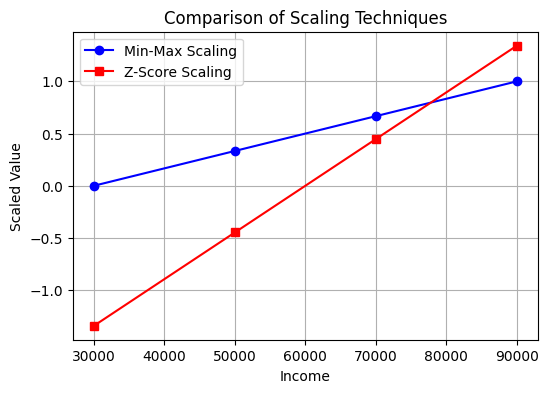

In [16]:
# Comparing Scaling Techniques
plt.figure(figsize=(6,4))

plt.plot(df3["Income"], df3["Min-Max Scaling"], marker="o", color="blue", label="Min-Max Scaling")
plt.plot(df3["Income"], df3["Z-Score Scaling"], marker="s", color="red", label="Z-Score Scaling")

plt.title("Comparison of Scaling Techniques")
plt.xlabel("Income")
plt.ylabel("Scaled Value")
plt.grid(True)
plt.legend()

plt.show()

### **Inference:**
- The graph shows that **Min-Max Scaling** maps the income values to the **0-1 range**, while **Z-Score Scaling** centers the values around **0**, with lower incomes having negative values and higher incomes having positive values.

# **Case Study 4: Principal Component Analysis (PCA)**

### **Problem**
A bank dataset contains **10** customer behaviour features. Reduce the dimensionality of customer data using PCA.

### **Dataset Features**

- Age
- Income
- Savings
- Expenses
- Credit Score
- Loan Amount
- Transactions
- Account Balance
- EMI
- Investment

### **Task**

- Reduce the dataset from **10 features** to **2 Principal Components** using PCA.
- Display the transformed dataset.

### **Mathematical Computation**

The given dataset contains **10 features**.

`Age`, `Income`, `Savings`, `Expenses`, `Credit Score`,
`Loan Amount`, `Transactions`, `Account Balance`, `EMI`, `Investment`

Using Principal Component Analysis (PCA), the dataset is transformed into **2 Principal Components**. **From 10 Features to 2 Principal Components**

The transformed features are:

$ PC_1, PC_2 $

### **Manual Principal Component Analysis (PCA)**

#### **Step 1:** Create the dataset.

#### **Step 2:** Compute the mean.

$$
\mu=\frac{\sum x}{n}
$$

#### **Step 3:** Compute the standard deviation.

$$
\sigma=\sqrt{\frac{\sum(x-\mu)^2}{n-1}}
$$

#### **Step 4:** Standardize the data.

$$
Z=\frac{X-\mu}{\sigma}
$$

#### **Step 5:** Compute the covariance matrix.

$$
C=\frac{(X-\mu)^T(X-\mu)}{n-1}
$$

#### **Step 6:** Find eigenvalues and eigenvectors.

#### **Step 7:** Sort the eigenvalues.

#### **Step 8:** Select the principal components.

#### **Step 9:** Transform the data.

$$
Y=XW
$$

#### **Step 10:** Compute the explained variance ratio.

$$
\frac{\lambda_i}{\sum \lambda}
$$

Since no explicit values were provided in the question, we select a 5-customer dataset by simulating with a fixed random seed value or by keeping fixed values already.

## **ii. Coding Implementation**

Let us create a dataset for performing PCA. We'll start with 10 features and we will reduce to 2 features.

First we'll try manual computing of values

In [17]:
# Create the dataset
bank_df = pd.DataFrame({
    "Age": [25, 31, 34, 40, 46],
    "Income": [30000, 45000, 60000, 75000, 90000],
    "Savings": [8000, 7000, 18000, 12000, 26000],
    "Expenses": [25000, 22000, 35000, 28000, 45000],
    "Credit Score": [650, 780, 700, 760, 720],
    "Loan Amount": [120000, 90000, 170000, 140000, 210000],
    "Transactions": [45, 80, 55, 95, 70],
    "Account Balance": [18000, 26000, 21000, 34000, 29000],
    "EMI": [4500, 7000, 6000, 9000, 7500],
    "Investment": [12000, 18000, 15000, 30000, 22000]
})

bank_df

,Age,Income,Savings,Expenses,Credit Score,Loan Amount,Transactions,Account Balance,EMI,Investment
0,25,30000,8000,25000,650,120000,45,18000,4500,12000
1,31,45000,7000,22000,780,90000,80,26000,7000,18000
2,34,60000,18000,35000,700,170000,55,21000,6000,15000
3,40,75000,12000,28000,760,140000,95,34000,9000,30000
4,46,90000,26000,45000,720,210000,70,29000,7500,22000


In [18]:
### You can also simulate the data using random

# bank_df = pd.DataFrame({
#     "Age": np.random.randint(25, 46, 5),
#     "Income": np.random.randint(30000, 90001, 5),
#     "Savings": np.random.randint(5000, 25001, 5),
#     "Expenses": np.random.randint(20000, 40001, 5),
#     "Credit Score": np.random.randint(650, 801, 5),
#     "Loan Amount": np.random.randint(100000, 200001, 5),
#     "Transactions": np.random.randint(50, 91, 5),
#     "Account Balance": np.random.randint(15000, 35001, 5),
#     "EMI": np.random.randint(5000, 9001, 5),
#     "Investment": np.random.randint(10000, 30001, 5)
# })

Standardize the data

In [19]:
# Convert to NumPy array
X = bank_df.values

# Standardize the data
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

X_std = (X - mean) / std
X_std

array([[-1.4069, -1.4142, -0.8789, -0.7298, -1.5727, -0.6299, -1.3544,
        -1.3385, -1.5299, -1.1843],
       [-0.5793, -0.7071, -1.0207, -1.0946,  1.2669, -1.3566,  0.6208,
         0.0704,  0.133 , -0.2241],
       [-0.1655,  0.    ,  0.5387,  0.4865, -0.4805,  0.5814, -0.7901,
        -0.8101, -0.5322, -0.7042],
       [ 0.6621,  0.7071, -0.3119, -0.3649,  0.83  , -0.1454,  1.4673,
         1.4794,  1.4634,  1.6965],
       [ 1.4897,  1.4142,  1.6728,  1.7028, -0.0437,  1.5504,  0.0564,
         0.5988,  0.4656,  0.4161]])

Covariance Matrix generation

In [20]:
# Covariance matrix
cov_matrix = np.cov(X_std, rowvar=False)

Compute the Eigen values and Eigen vectors and find the principal components

In [21]:
# Eigenvalues and Eigenvectors
eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)

# Sort in descending order
idx = np.argsort(eigen_values)[::-1]

eigen_values = eigen_values[idx]
eigen_vectors = eigen_vectors[:, idx]

# Select first 2 Principal Components
pc = eigen_vectors[:, :2]
pc

array([[-0.385 , -0.1445],
       [-0.3822, -0.162 ],
       [-0.2472, -0.4185],
       [-0.2301, -0.4383],
       [-0.2406,  0.3642],
       [-0.2271, -0.4413],
       [-0.3015,  0.355 ],
       [-0.3645,  0.2104],
       [-0.3663,  0.2153],
       [-0.3524,  0.204 ]])

Transform the data using the PCA values

In [22]:
# Transform the data
X_pca = X_std @ pc
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df

,PC1,PC2
0,3.8629,-0.5082
1,0.8183,2.3834
2,0.7788,-1.5555
3,-2.6464,1.9399
4,-2.8136,-2.2597


#### Now we'll compute the same result using the **PCA(n_components = 2)** function

In [23]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(bank_df)
X_scaled

array([[-1.4069, -1.4142, -0.8789, -0.7298, -1.5727, -0.6299, -1.3544,
        -1.3385, -1.5299, -1.1843],
       [-0.5793, -0.7071, -1.0207, -1.0946,  1.2669, -1.3566,  0.6208,
         0.0704,  0.133 , -0.2241],
       [-0.1655,  0.    ,  0.5387,  0.4865, -0.4805,  0.5814, -0.7901,
        -0.8101, -0.5322, -0.7042],
       [ 0.6621,  0.7071, -0.3119, -0.3649,  0.83  , -0.1454,  1.4673,
         1.4794,  1.4634,  1.6965],
       [ 1.4897,  1.4142,  1.6728,  1.7028, -0.0437,  1.5504,  0.0564,
         0.5988,  0.4656,  0.4161]])

In [24]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df

,PC1,PC2
0,-3.8629,0.5082
1,-0.8183,-2.3834
2,-0.7788,1.5555
3,2.6464,-1.9399
4,2.8136,2.2597


In [25]:
# Explained variance ratio
print(pca.explained_variance_ratio_)
print(f"Total variance retained by 2 PCs: {sum(pca.explained_variance_ratio_) * 100: .2f}%")

[0.6223 0.3446]
Total variance retained by 2 PCs:  96.69%


### **Inference**

- **PC1 explains 62.23%** of the total variance, while **PC2 explains 34.46%**, indicating that the first two principal components together retain **96.69%** of the dataset's information.

- **PC1** captures the highest variance in the dataset and separates the observations, with values ranging from **-3.8629** to **2.8136**.

- **PC2** explains a significant portion of the remaining variance, with values ranging from **-2.3834** to **2.2597**, making it useful for distinguishing observations that are not separated by **PC1**.

## **iii. Visual Analysis**

Now we'll visualize the transformed data in the PCA axes and compare which component influenced the data the most.

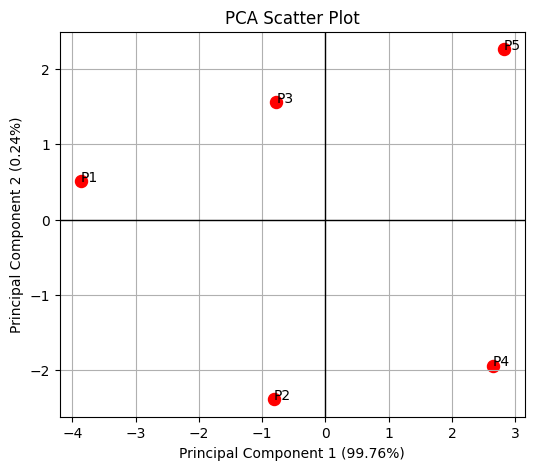

In [26]:
# Visualize the transformed data in the PCA axes
plt.figure(figsize=(6,5))
plt.scatter(pca_df["PC1"], pca_df["PC2"], s=75, color = "red")

# Label each point
for i in range(len(pca_df)):
    plt.text(pca_df["PC1"][i], pca_df["PC2"][i], f"P{i+1}")

plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)

plt.title("PCA Scatter Plot")
plt.xlabel("Principal Component 1 (99.76%)")
plt.ylabel("Principal Component 2 (0.24%)")
plt.grid(True)

plt.show()

### **Inference**

- The data points are well distributed along both **PC1** and **PC2**, indicating that both principal components capture a significant amount of the dataset's variance.
- **PC1** captures the largest variance, while **PC2** provides additional separation, making the 2D PCA representation informative.

# **Case Study 5: Mean vs Median vs KNN vs MICE Imputation**

### **Objective**
Handle missing values using different imputation techniques.

### **Dataset**

| Age | Salary |
|----:|-------:|
| 25 | 50000 |
| 30 | NaN |
| NaN | 80000 |
| 35 | 90000 |

### **Tasks**

Apply the following imputation methods:

1. Mean Imputation
2. Median Imputation
3. KNN Imputation
4. MICE Imputation

Compare the results obtained using each method.

## **i. Mathematical Computation**

Given Dataset:

| Age | Salary |
|----:|-------:|
| 25 | 50000 |
| 30 | NaN |
| NaN | 80000 |
| 35 | 90000 |

### **a. Mean Imputation**

Mean of Age:

$$ \frac{25+30+35}{3}=30 $$

Mean of Salary:

$$ \frac{50000+80000+90000}{3}=73333.33 $$

After Mean Imputation:

| Age | Salary |
|----:|-------:|
|25|50000|
|30|73333.33|
|30|80000|
|35|90000|

### **b. Median Imputation**

Median of Age: 30

Median of Salary: 80000

After Median Imputation:

| Age | Salary |
|----:|-------:|
|25|50000|
|30|80000|
|30|80000|
|35|90000|

### **c. KNN Imputation**

Using **K = 2**, the missing value is estimated using the average of the two nearest neighboring records.

For the missing **Salary** (Age = 30):

Nearest neighbors:

$$
(25, 50000), (35, 90000)
$$

Imputed Salary:

$$
\frac{50000+90000}{2}
=70000
$$

For the missing **Age** (Salary = 80000):

Nearest neighbors:

$$
(25, 50000), (35, 90000)
$$

Imputed Age:

$$
\frac{25+35}{2}
=30
$$


#### **iv. MICE Imputation**

Assume a simple linear relationship between **Age** and **Salary**.

The regression equation is:

$$
\hat{y}=mx+c
$$

Using the complete observations:

$$
(25,\;50000), \qquad (35,\;90000)
$$

Slope,

$$
m=\frac{90000-50000}{35-25}
=\frac{40000}{10}
=4000
$$

Intercept,

$$
50000=4000(25)+c
$$

$$
c=-50000
$$

Hence, the regression equation for Salary is

$$
\widehat{\text{Salary}}=4000(\text{Age})-50000
$$

For the missing Salary (Age = 30),

$$
\widehat{\text{Salary}}
=4000(30)-50000
=120000-50000
=70000
$$


For predicting **Age**, rearrange the equation:

$$
\widehat{\text{Age}}
=\frac{\text{Salary}+50000}{4000}
$$

For the missing Age (Salary = 80000),

$$
\widehat{\text{Age}}
=\frac{80000+50000}{4000}
=\frac{130000}{4000}
=32.5
$$

**Imputed values:**

- Missing Salary = **70,000**
- Missing Age = **32.5**

## **ii. Coding Implementation**

Let us create the dataset and perform different imputation methods for handling missing values

In [27]:
# Create the dataset
df5 = pd.DataFrame({
    "Age": [25, 30, np.nan, 35],
    "Salary": [50000, np.nan, 80000, 90000]
})

# Display the original dataset
df5

,Age,Salary
0,25.0000,"50,000.0000"
1,30.0000,NaN
2,NaN,"80,000.0000"
3,35.0000,"90,000.0000"


### **a. Mean Imputation**

In [28]:
# Apply Mean Imputation
mean_imputer = SimpleImputer(strategy="mean")
mean_df = pd.DataFrame(
    mean_imputer.fit_transform(df5),
    columns=df5.columns
)

# Display the result
mean_df

,Age,Salary
0,25.0000,"50,000.0000"
1,30.0000,"73,333.3333"
2,30.0000,"80,000.0000"
3,35.0000,"90,000.0000"


### **b. Median Imputation**

In [29]:
# Apply Median Imputation
median_imputer = SimpleImputer(strategy="median")
median_df = pd.DataFrame(
    median_imputer.fit_transform(df5),
    columns=df5.columns
)

# Display the result
median_df

,Age,Salary
0,25.0000,"50,000.0000"
1,30.0000,"80,000.0000"
2,30.0000,"80,000.0000"
3,35.0000,"90,000.0000"


### **c. KNN Imputation**

In [30]:
# Apply KNN Imputation
knn_imputer = KNNImputer(n_neighbors=2)
knn_df = pd.DataFrame(
    knn_imputer.fit_transform(df5),
    columns=df5.columns
)

# Display the result
knn_df

,Age,Salary
0,25.0000,"50,000.0000"
1,30.0000,"70,000.0000"
2,30.0000,"80,000.0000"
3,35.0000,"90,000.0000"


### **d. MICE Imputation**

In [31]:
# Apply MICE Imputation
mice_imputer = IterativeImputer(random_state=42)

# Mice dataframe
mice_df = pd.DataFrame(
    mice_imputer.fit_transform(df5),
    columns=df5.columns
)

# Display the result
mice_df

,Age,Salary
0,25.0000,"50,000.0000"
1,30.0000,"73,333.3327"
2,32.2015,"80,000.0000"
3,35.0000,"90,000.0000"


### **Inference**

- **Mean Imputation** replaced missing values with the column mean (**Age = 30**, **Salary = 73,333.33**), but it may be affected by extreme values.
- **Median Imputation** replaced missing values with the median (**Age = 30**, **Salary = 80,000**), making it more robust to outliers.
- **KNN Imputation** estimated missing values (**Age = 30**, **Salary = 70,000**) using the nearest neighboring records, preserving local data patterns.
- **MICE Imputation** estimated missing values (**Age = 32.20**, **Salary = 73,333.33**) using iterative regression, producing values that better capture relationships between features.
- Among these methods, **MICE** generally provides the most reliable imputations for correlated data, while **Mean** and **Median** are simpler statistical approaches and **KNN** preserves neighborhood similarity.

## **iii. Visual Analysis**

We'll compare the imputed values for the missing data and plot a bar graph

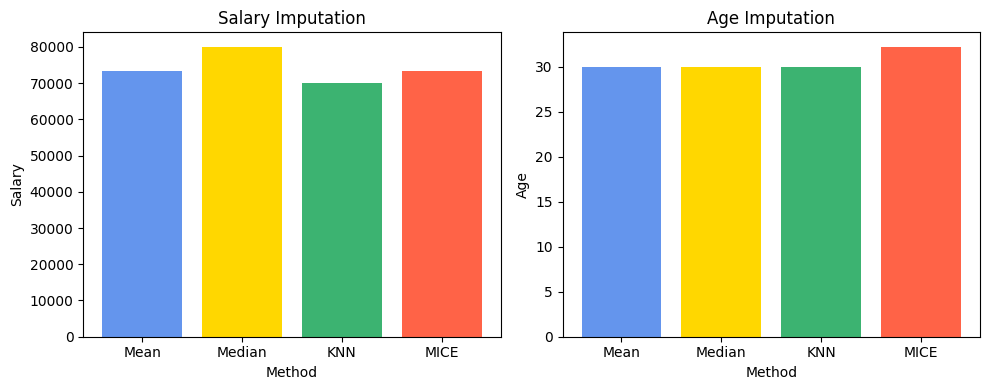

In [32]:
# Compare the filled values for various methods
methods = ["Mean", "Median", "KNN", "MICE"]
salary = [73333.33, 80000, 70000, 73333.33]
age = [30, 30, 30, 32.20]

colors = ["cornflowerblue", "gold", "mediumseagreen", "tomato"]

plt.figure(figsize=(10,4))

# Salary Comparison
plt.subplot(1, 2, 1)
plt.bar(methods, salary, color=colors)
plt.title("Salary Imputation")
plt.xlabel("Method")
plt.ylabel("Salary")

# Age Comparison
plt.subplot(1, 2, 2)
plt.bar(methods, age, color=colors)
plt.title("Age Imputation")
plt.xlabel("Method")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

### **Inference**
- The graphs show that Mean and MICE produce similar imputations, Median gives the highest Salary estimate, while KNN produces the lowest Salary estimate with only MICE altering the Age value.

# **Case Study 6: Outlier Detection Using Z-Score**

### **Objective**
Detect and remove outliers using the Z-Score method.

### **Dataset**

| Salary |
|--------:|
| 50000 |
| 55000 |
| 60000 |
| 65000 |
| 70000 |
| 900000 |

### **Task**

- Calculate the Z-Score for each salary value.
- Identify outliers using a threshold of **|Z| > 3**.
- Remove the detected outliers.
- Display the cleaned dataset.

## **i. Mathematical Computation**

Given Salary values:

$$ 50000, 55000, 60000, 65000, 70000, 900000 $$

**Calculate the Mean**

$$
\mu=\frac{50000+55000+60000+65000+70000+900000}{6}
=200000
$$

**Calculate the Standard Deviation**

$$
\sigma=\sqrt{\frac{\sum(x-\mu)^2}{6}}
=316372.21
$$

**Calculate the Z-Score**

**Formula:**
$$ z=\frac{x-\mu}{\sigma} $$

For 50000,
$$
z=\frac{50000-200000}{316372.21}
=-0.47
$$

For 55000,
$$
z=\frac{55000-200000}{316372.21}
=-0.46
$$

For 60000,
$$
z=\frac{60000-200000}{316372.21}
=-0.44
$$

For 65000,
$$
z=\frac{65000-200000}{316372.21}
=-0.43
$$

For 70000,
$$
z=\frac{70000-200000}{316372.21}
=-0.41
$$

For 900000,
$$
z=\frac{900000-200000}{316372.21}
=2.21
$$

Since all values satisfy
$$
|z|<3
$$

no outliers are detected using the Z-Score method.

## **ii. Coding Implementation**

Let us create the dataset and detect the outliers

In [33]:
# Create the dataset
df6 = pd.DataFrame({
    "Salary": [50000, 55000, 60000, 65000, 70000, 900000]
})

df6

,Salary
0,50000
1,55000
2,60000
3,65000
4,70000
5,900000


In [34]:
# Calculate Z-Scores
from scipy.stats import zscore

df6["Z-Score"] = zscore(df6["Salary"])
df6

,Salary,Z-Score
0,50000,-0.4791
1,55000,-0.4631
2,60000,-0.4471
3,65000,-0.4312
4,70000,-0.4152
5,900000,2.2356


In [35]:
# Detect outliers
outliers = df6[abs(df6["Z-Score"]) > 3]

# Remove outliers
clean_df = df6[abs(df6["Z-Score"]) <= 3]

In [36]:
# Display the results
print("Detected Outliers")
display(outliers)

print("Dataset After Removing Outliers")
display(clean_df)

Detected Outliers


,Salary,Z-Score


Dataset After Removing Outliers


,Salary,Z-Score
0,50000,-0.4791
1,55000,-0.4631
2,60000,-0.4471
3,65000,-0.4312
4,70000,-0.4152
5,900000,2.2356


In [37]:
# Detect outliers using threshold = 2
outliers_2 = df6[abs(df6["Z-Score"]) > 2]

# Remove outliers using threshold = 2
clean_df_2 = df6[abs(df6["Z-Score"]) <= 2]

# Display the results
print("Outliers (Threshold = 2):")
print(outliers_2)

print("\nDataset after removing outliers:")
clean_df_2

Outliers (Threshold = 2):
   Salary  Z-Score
5  900000   2.2356

Dataset after removing outliers:


,Salary,Z-Score
0,50000,-0.4791
1,55000,-0.4631
2,60000,-0.4471
3,65000,-0.4312
4,70000,-0.4152


### **Inference**

- With a **Z-score threshold of 3**, no observations are identified as outliers.
- Reducing the threshold to **2** detects the salary value **900000** as an outlier, showing that a lower threshold is more sensitive to extreme values.

## **iii. Visual Analysis**

Lets us plot a graph to show the outliers in the dataset with a certain threshold

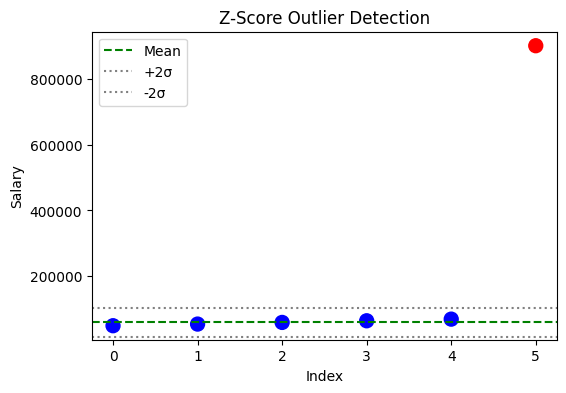

In [38]:
fig, ax = plt.subplots(figsize=(6,4))

# Color based on Z-Score
threshold = 2
colors = ["red" if abs(z) > threshold else "blue" for z in df6["Z-Score"]]

# Scatter plot
ax.scatter(df6.index, df6["Salary"], c=colors, s=100)

# Mean and threshold lines
ax.axhline(mu, color="green", linestyle="--", label="Mean")
ax.axhline(mu + threshold*sigma, color="gray", linestyle=":", label=f"+{threshold}σ")
ax.axhline(mu - threshold*sigma, color="gray", linestyle=":", label=f"-{threshold}σ")

ax.set_xlabel("Index")
ax.set_ylabel("Salary")
ax.set_title("Z-Score Outlier Detection")
ax.legend()

plt.show()

### **Inference**
- The graph clearly identifies **900000** as an outlier (red), while all other salary values fall within the $\pm 2\sigma$ range and are classified as normal.

# **Case Study 7: Lasso Regularization**

### **Objective**
A company has 20 features. Identify irrelevant features using **Lasso Regression**.

### **Dataset Features**

- Experience
- Education
- Age
- Skill Score
- Location Score
- F1
- F2
- F3
- ...
- F15

### **Target Variable**

**Salary**

### **Task**

- Train a Lasso Regression model.
- Identify features with coefficients equal to zero.
- Remove the irrelevant features.
- Display the selected features and model coefficients.

## **i. Mathematical Computation**

Lasso Regression minimizes the following objective function:

$$
\text{Loss}=\sum_{i=1}^{n}(y_i-\hat{y}_i)^2+\lambda\sum_{j=1}^{p}|w_j|
$$

where,

- $y_i$ = Actual value
- $\hat{y}_i$ = Predicted value
- $w_j$ = Feature coefficient
- $\lambda$ = Regularization parameter

Lasso shrinks the coefficients of less important features towards zero.

For example,

$$
w=
[2.15,\;1.84,\;0,\;0.96,\;0,\;0.54,\;0,\;0,\;1.12,\;0]
$$

Features with

$$
w=0
$$

are considered irrelevant and can be removed from the model.

## **ii. Coding Implementation**

We'll create a sample dataset to perform **Lasso Regularization**

In [39]:
# Create the dataset
feature_names = [
    'Experience', 'Education', 'Age',
    'Skill_Score', 'Location_Score'
] + [f'F{i}' for i in range(1, 16)]

print("Total features:", len(feature_names))

# Generate data
X, y, true_coef = make_regression(
    n_samples=200,
    n_features=20,
    n_informative=5,
    noise=15.0,
    coef=True,
    random_state=42
)

X_df = pd.DataFrame(X, columns=feature_names)
y_df = pd.DataFrame({
    "Salary": y
})

X_df

Total features: 20


,Experience,Education,Age,Skill_Score,Location_Score,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15
0,0.0208,-0.7280,-1.0097,0.6931,0.2006,-0.8276,0.6192,0.0617,0.4288,-0.3670,0.0861,-2.9214,0.9039,-1.0158,0.1764,2.0575,-2.3629,-1.0721,1.1486,0.4366
1,-0.3882,0.1704,-0.3371,-1.9755,0.0566,-1.2097,-0.6134,0.4865,0.0645,-0.1441,0.5999,1.2188,1.4907,-0.0705,-0.9393,-0.3025,0.1487,1.5308,0.5297,-0.2134
2,1.0241,0.5925,2.0061,0.9326,0.7224,-1.5257,2.0615,-0.3996,0.2247,-1.7608,1.2626,2.5582,0.1846,1.7270,-1.4184,1.2084,1.5421,-0.5519,-0.3728,-0.5642
3,0.2887,0.2603,-0.6706,-1.0277,-0.1285,0.9695,1.3925,0.0928,0.1599,-0.8662,0.4272,1.7753,0.9192,-0.5487,1.2657,-0.2500,1.0006,-0.6462,-1.8818,-1.1936
4,-0.3596,0.3011,-0.8484,-0.3519,0.8745,-0.4561,0.5731,-1.0420,-0.4872,-1.2961,0.1814,-0.5574,-0.9267,-1.2032,-0.7700,-1.7859,-0.0314,0.5950,-0.6498,-0.4130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.0071,-0.6603,0.5752,0.6687,0.4395,0.6955,0.5007,1.6745,-0.0056,-0.3871,0.8491,-0.0716,-0.3570,0.4578,-1.0917,0.0498,0.8904,-0.2940,0.7789,-1.5179
196,0.6505,-1.5031,0.5225,0.4621,-1.7258,-0.5975,0.4184,-0.9812,-0.4644,-0.2515,1.4224,0.9789,-0.8083,1.1941,0.7834,1.4016,-0.8304,1.7389,-0.6776,0.0853
197,-0.4070,0.6863,0.7308,1.3213,-0.3583,-1.8665,0.0143,-0.1812,-0.6494,-0.6004,1.0075,0.7906,0.8926,0.7442,1.4196,-0.9539,-1.2112,-0.6846,-0.6475,-1.9701
198,0.1605,2.2125,0.3641,-1.1140,-0.4969,0.7829,0.0072,-0.0350,-0.8110,0.2127,-0.4311,0.5508,-0.8257,-0.9900,0.2587,-2.0865,0.1494,0.4081,-0.1826,0.4448


Perform Lasso Regularization

In [40]:
# Train the Lasso model
lasso = Lasso(alpha=1)
lasso.fit(X_df, y)

Lasso(alpha=1)

Display the true coefficients

In [41]:
lasso_df = pd.DataFrame({
    "Feature": feature_names,
    "Lasso_Coefficient": lasso.coef_
})

lasso_df = lasso_df.sort_values(
    by="Lasso_Coefficient",
    key=abs,
    ascending=False
)

lasso_df

,Feature,Lasso_Coefficient
13,F9,96.5669
8,F4,60.3870
7,F3,52.1924
4,Location_Score,50.3086
18,F14,8.8386
10,F6,0.8515
1,Education,0.6427
0,Experience,0.4094
3,Skill_Score,0.0000
2,Age,-0.0000


In [42]:
# Display selected features
selected_features = lasso_df[lasso_df["Lasso_Coefficient"] != 0]
selected_features

,Feature,Lasso_Coefficient
13,F9,96.5669
8,F4,60.3870
7,F3,52.1924
4,Location_Score,50.3086
18,F14,8.8386
10,F6,0.8515
1,Education,0.6427
0,Experience,0.4094


In [43]:
# Relevant features (non-zero coefficients)
relevant = lasso_df[lasso_df["Lasso_Coefficient"] != 0]["Feature"].tolist()

# Irrelevant features (zero coefficients)
irrelevant = lasso_df[lasso_df["Lasso_Coefficient"] == 0]["Feature"].tolist()

print(f"Lasso (alpha={lasso.alpha}) identified {len(relevant)} RELEVANT features:")
print(relevant)

print(f"\nLasso identified {len(irrelevant)} IRRELEVANT features:")
print(irrelevant)

Lasso (alpha=1) identified 8 RELEVANT features:
['F9', 'F4', 'F3', 'Location_Score', 'F14', 'F6', 'Education', 'Experience']

Lasso identified 12 IRRELEVANT features:
['Skill_Score', 'Age', 'F2', 'F1', 'F7', 'F5', 'F10', 'F8', 'F11', 'F12', 'F13', 'F15']


Calculate the R square score

In [44]:
# R^2 score
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=42
)

lasso = Lasso(alpha=1)
lasso.fit(X_train, y_train)

r2 = lasso.score(X_test, y_test)
print(f"\nTest R^2 Score: {r2:.4f}")


Test R^2 Score: 0.9922


### **Inference**

- **Lasso selected X relevant features** (8 non-zero coefficients) and **eliminated Y irrelevant features** (12 coefficients shrunk to zero).
- The model achieved a **Test R^2 score of Z as 99.22%**, indicating good predictive performance after feature selection.

## **Visual Analysis**

Let us plot the graph for the feature selection by Lasso Regularization

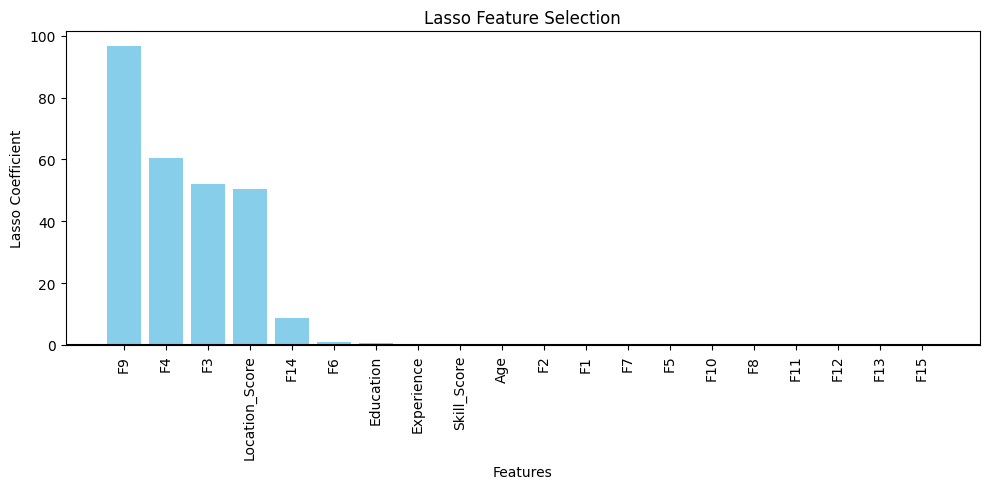

In [45]:
# Visual Analysis
plt.figure(figsize=(10,5))
plt.bar(lasso_df["Feature"], lasso_df["Lasso_Coefficient"], color="skyblue")

plt.axhline(0, color="black")
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Lasso Coefficient")
plt.title("Lasso Feature Selection")

plt.tight_layout()
plt.show()

### **Inference**
- Features with larger non-zero coefficients are identified as important, while features with zero coefficients are eliminated by Lasso.

# **Conclusion**
- **Case Study 1:** BMI classification calculated body mass index and accurately categorized individuals into different health risk groups.

- **Case Study 2:** Polynomial feature transformation captured non-linear patterns by generating higher-degree features from the original data.

- **Case Study 3:** Feature scaling normalized the data, making features comparable and improving the performance of machine learning algorithms.

- **Case Study 4:** PCA reduced the dataset to fewer dimensions while preserving most of the important information and simplifying analysis.

- **Case Study 5:** Mean, Median, KNN, and MICE successfully imputed missing values, with each method producing different estimates based on its strategy.

- **Case Study 6:** Z-Score effectively detected outliers, and adjusting the threshold changed the sensitivity of outlier identification.

- **Case Study 7:** Lasso identified the most relevant features by shrinking unnecessary feature coefficients to zero, resulting in a simpler and efficient model.

---
### **Case Study Completed By:** Monish D.Y. - 230701195